# Sistema de Recomendacion de Trayectorias Profesionales
### Adult Census Income Dataset




In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


## Paso 1: Carga del conjunto de datos

In [2]:
df = pd.read_csv("https://breathecode.herokuapp.com/asset/internal-link?id=2326&path=adult-census-income.csv")
df.head()


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## EDA y limpieza

In [3]:
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
print(f"Duplicados: {df.duplicated().sum()}")
df = df.drop_duplicates().reset_index(drop=True)


Filas: 32561, Columnas: 15
Duplicados: 24


In [4]:
# El dataset usa "?" para valores faltantes en vez de NaN -- hay que detectarlo explicitamente,
# pandas no lo reconoce como nulo por defecto
for col in df.columns:
    n_missing = (df[col] == "?").sum()
    if n_missing > 0:
        print(f"{col}: {n_missing} valores '?' ({100*n_missing/len(df):.1f}%)")


workclass: 1836 valores '?' (5.6%)
occupation: 1843 valores '?' (5.7%)
native.country: 582 valores '?' (1.8%)


In [5]:
rows_before = len(df)
df = df.replace("?", pd.NA).dropna().reset_index(drop=True)
print(f"Filas antes: {rows_before}, despues: {len(df)} (se perdio {100*(rows_before-len(df))/rows_before:.1f}%)")


Filas antes: 32537, despues: 30139 (se perdio 7.4%)


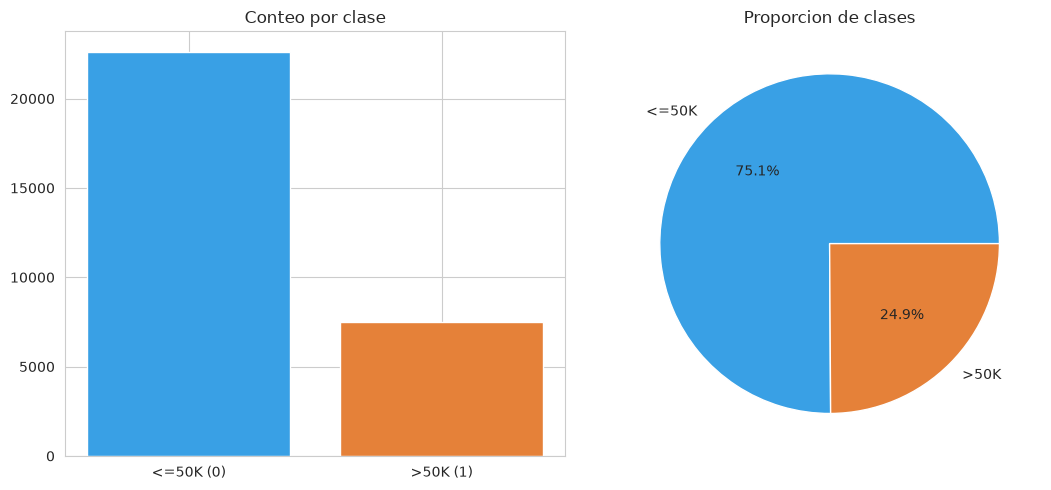

high_income
0    0.751
1    0.249
Name: proportion, dtype: float64


In [6]:
df["income"] = df["income"].str.strip()
df["high_income"] = (df["income"] == ">50K").astype(int)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
counts = df["high_income"].value_counts()
axes[0].bar(["<=50K (0)", ">50K (1)"], counts.values, color=["#39A0E5", "#E58139"])
axes[0].set_title("Conteo por clase")
axes[1].pie(counts.values, labels=["<=50K", ">50K"], autopct="%1.1f%%", colors=["#39A0E5", "#E58139"])
axes[1].set_title("Proporcion de clases")
plt.tight_layout()
plt.show()

print(df["high_income"].value_counts(normalize=True).round(3))


Las clases estan moderadamente desbalanceadas (~76% / 24%) -- importante tenerlo en cuenta al evaluar el modelo mas adelante: el accuracy solo puede ser enganoso, igual que en el proyecto de diabetes.

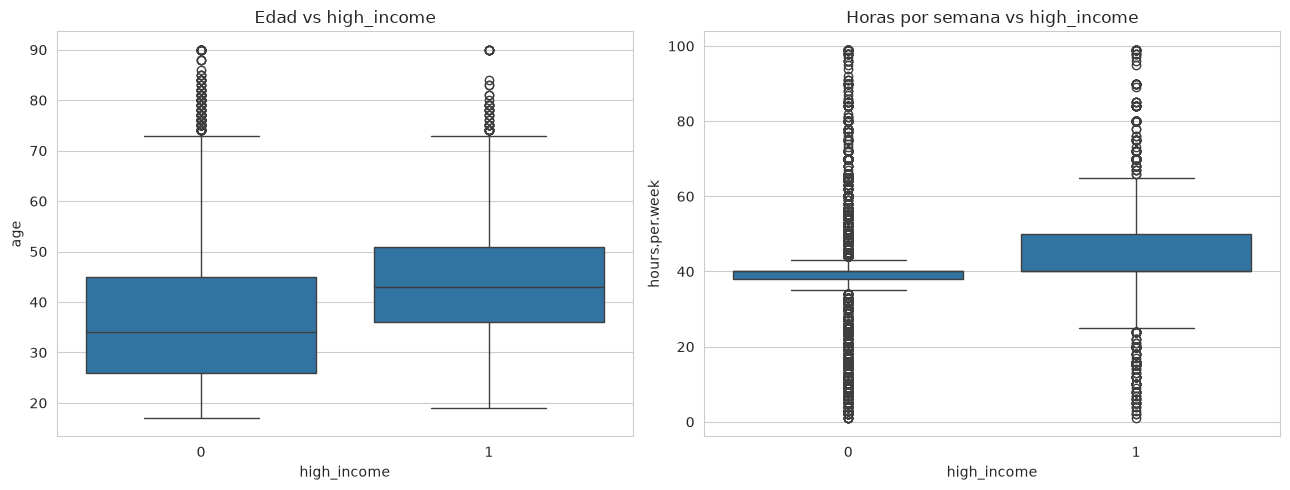

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=df, x="high_income", y="age", ax=axes[0])
axes[0].set_title("Edad vs high_income")
sns.boxplot(data=df, x="high_income", y="hours.per.week", ax=axes[1])
axes[1].set_title("Horas por semana vs high_income")
plt.tight_layout()
plt.show()


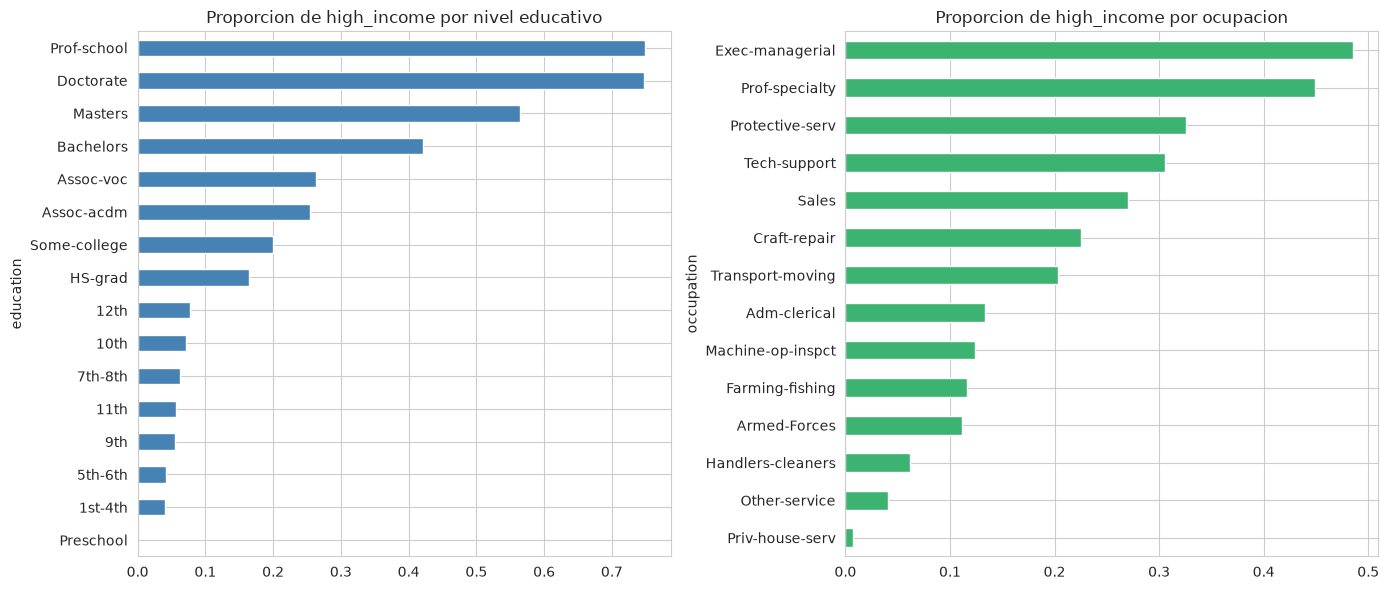

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
df.groupby("education")["high_income"].mean().sort_values().plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Proporcion de high_income por nivel educativo")
df.groupby("occupation")["high_income"].mean().sort_values().plot(kind="barh", ax=axes[1], color="mediumseagreen")
axes[1].set_title("Proporcion de high_income por ocupacion")
plt.tight_layout()
plt.show()


Se confirma lo esperable: niveles educativos mas altos (`Doctorate`, `Prof-school`, `Masters`) y ciertas ocupaciones (`Exec-managerial`, `Prof-specialty`) tienen una proporcion mucho mayor de ingresos altos -- estas son justo las variables sobre las que va a actuar el sistema de recomendacion.

In [9]:
print(f"native.country tiene {df['native.country'].nunique()} categorias distintas")
print(df["native.country"].value_counts().tail(10))


native.country tiene 41 categorias distintas
native.country
Trinadad&Tobago               18
Cambodia                      18
Laos                          17
Thailand                      17
Yugoslavia                    16
Outlying-US(Guam-USVI-etc)    14
Hungary                       13
Honduras                      12
Scotland                      11
Holand-Netherlands             1
Name: count, dtype: int64


**Hallazgo de EDA que lleva a una decision de preprocesamiento:** `native.country` tiene 42 categorias, muchas con muy pocos casos (`Holland-Netherlands` tiene un solo registro en todo el dataset). Con one-hot encoding, esas categorias raras generan columnas casi vacias que aportan ruido y pueden hacer que el modelo generalice peor. Se agrupan los paises con menos de 50 registros en una categoria `"Other"`.

In [10]:
country_counts = df["native.country"].value_counts()
rare_countries = country_counts[country_counts < 50].index
df["native.country"] = df["native.country"].apply(lambda x: "Other" if x in rare_countries else x)
print(f"Categorias de native.country despues de agrupar: {df['native.country'].nunique()}")


Categorias de native.country despues de agrupar: 21


## Paso 3: Definicion del problema de recomendacion

- **Que se quiere recomendar:** trayectorias profesionales, entendidas como combinaciones de `education` + `occupation` que una persona podria alcanzar, evaluadas por cuanto aumentarian su probabilidad estimada de ingreso alto a los 40 anios.
- **Quien es el "usuario":** una persona descrita por su perfil sociodemografico actual (edad, educacion, estado civil, ocupacion, horas trabajadas, sexo, pais de origen).
- **Variables que definen el perfil:** las mismas 7 columnas usadas como features del modelo: `age`, `education`, `marital.status`, `occupation`, `hours.per.week`, `sex`, `native.country`.

**Enfoque elegido: filtrado basado en contenido, hibridado con un modelo de scoring.**
1. Cada trayectoria candidata (combinacion real de `education`+`occupation` observada en los datos) se representa como un **vector**, usando el mismo preprocesamiento (escalado + one-hot) que el modelo.
2. Se calcula la **similitud coseno** entre el vector del perfil actual del usuario y cada trayectoria candidata -- esto favorece recomendaciones realistas/alcanzables, no saltos completamente descabellados.
3. Entre las trayectorias mas similares, se usa el modelo de clasificacion (entrenado para predecir `high_income`) para **puntuar** cual de ellas maximiza la probabilidad de ingreso alto.
4. Se recomiendan las trayectorias con mejor combinacion de similitud + probabilidad predicha.



## Preprocesamiento y pipeline del modelo

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

features = ["age", "education", "marital.status", "occupation", "hours.per.week", "sex", "native.country"]
X = df[features]
y = df["high_income"]

numeric_features = ["age", "hours.per.week"]
categorical_features = ["education", "marital.status", "occupation", "sex", "native.country"]

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42)),
])


In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
model.fit(X_train, y_train)
print("Modelo entrenado.")


Modelo entrenado.


## Evaluacion del modelo (faltaba por completo en la solucion original)

La solucion de referencia nunca evaluaba el modelo contra `X_test`/`y_test` -- pasaba directo de entrenar a simular un usuario inventado, sin ninguna evidencia de que tan bueno era el modelo. Esto es indispensable antes de confiar en el sistema de recomendacion que se construye sobre el.

              precision    recall  f1-score   support

       <=50K       0.86      0.92      0.89      4527
        >50K       0.70      0.56      0.62      1501

    accuracy                           0.83      6028
   macro avg       0.78      0.74      0.76      6028
weighted avg       0.82      0.83      0.82      6028



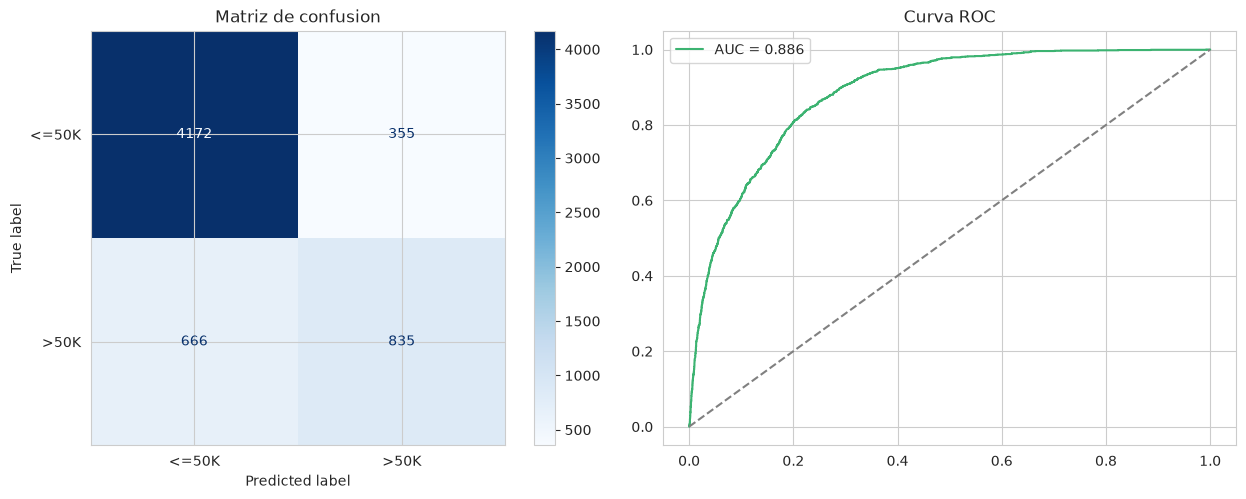

In [13]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["<=50K", ">50K"]))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=["<=50K", ">50K"]).plot(ax=axes[0], cmap="Blues")
axes[0].set_title("Matriz de confusion")

fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr, tpr, label=f"AUC = {auc:.3f}", color="mediumseagreen")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_title("Curva ROC")
axes[1].legend()
plt.tight_layout()
plt.show()


El modelo tiene un AUC solido (~0.89) y un recall razonable para la clase minoritaria (`>50K`), aunque como es esperable con desbalance de clases, el recall de esa clase es menor que el de la mayoritaria -- es informacion util a tener en cuenta: el sistema de recomendacion hereda esta incertidumbre del modelo base.

## Paso 4: Construccion del sistema de recomendacion

In [14]:
# Catalogo de trayectorias candidatas: combinaciones reales de educacion + ocupacion
# observadas en los datos (no combinaciones inventadas al azar)
catalog = df[["education", "occupation"]].drop_duplicates().reset_index(drop=True)
print(f"Trayectorias candidatas en el catalogo: {len(catalog)}")


Trayectorias candidatas en el catalogo: 198


In [15]:
from sklearn.metrics.pairwise import cosine_similarity

TARGET_AGE = 40  # el objetivo declarado del proyecto: probabilidad de ingreso alto a los 40 anios

def recommend_trajectory(user_profile, target_age=TARGET_AGE, top_n=3, similarity_pool=30):
    """
    user_profile: dict con las claves age, education, marital.status, occupation,
    hours.per.week, sex, native.country (mismo formato que el dataset original).

    Devuelve la probabilidad actual estimada (a target_age, con el perfil actual) y
    las top_n trayectorias recomendadas, priorizando primero similitud (realismo)
    y despues probabilidad de ingreso alto (mejora).
    """
    base = user_profile.copy()
    base["age"] = target_age
    base_df = pd.DataFrame([base])[features]
    current_prob = model.predict_proba(base_df)[0][1]

    candidates = catalog.copy()
    candidates["age"] = target_age
    candidates["marital.status"] = user_profile["marital.status"]
    candidates["hours.per.week"] = user_profile["hours.per.week"]
    candidates["sex"] = user_profile["sex"]
    candidates["native.country"] = user_profile["native.country"]
    candidates = candidates[features]

    candidates["predicted_prob"] = model.predict_proba(candidates)[:, 1]

    # Vectores usando el MISMO preprocesador ya ajustado -- para que la similitud sea consistente
    user_vec = model.named_steps["preprocessor"].transform(base_df)
    cand_vecs = model.named_steps["preprocessor"].transform(candidates[features])
    candidates["similarity"] = cosine_similarity(user_vec, cand_vecs)[0]

    # Filtrar primero por similitud (trayectorias realistas/alcanzables),
    # y entre esas, ordenar por probabilidad predicha
    pool = candidates.sort_values("similarity", ascending=False).head(similarity_pool)
    top = pool.sort_values("predicted_prob", ascending=False).head(top_n)

    return current_prob, top[["education", "occupation", "predicted_prob", "similarity"]].reset_index(drop=True)


**Correccion del objetivo del proyecto:** la solucion de referencia usaba la edad *actual* del usuario para predecir, aunque el objetivo declarado del proyecto es "la probabilidad de ganar mas de 50K **a los 40 anios**". Aqui `target_age=40` se fija explicitamente al construir tanto el perfil base como cada candidato -- todas las comparaciones son "si esta persona tuviera 40 anios", consistente con el objetivo real del proyecto.

## Paso 5: Pruebas con casos simulados

In [16]:
perfil_usuario_1 = {
    "age": 25,
    "education": "HS-grad",
    "marital.status": "Never-married",
    "occupation": "Sales",
    "hours.per.week": 30,
    "sex": "Male",
    "native.country": "United-States",
}

current_prob, recomendaciones = recommend_trajectory(perfil_usuario_1)
print(f"Probabilidad estimada a los {TARGET_AGE} anios manteniendo el perfil actual: {current_prob*100:.1f}%")
print("\nTrayectorias recomendadas:")
recomendaciones


Probabilidad estimada a los 40 anios manteniendo el perfil actual: 3.1%

Trayectorias recomendadas:


,education,occupation,predicted_prob,similarity
0,Prof-school,Sales,0.230723,0.829005
1,Doctorate,Sales,0.214103,0.829005
2,Masters,Exec-managerial,0.197610,0.658011


In [17]:
perfil_usuario_2 = {
    "age": 30,
    "education": "Bachelors",
    "marital.status": "Married-civ-spouse",
    "occupation": "Adm-clerical",
    "hours.per.week": 40,
    "sex": "Female",
    "native.country": "United-States",
}

current_prob2, recomendaciones2 = recommend_trajectory(perfil_usuario_2)
print(f"Probabilidad estimada a los {TARGET_AGE} anios manteniendo el perfil actual: {current_prob2*100:.1f}%")
print("\nTrayectorias recomendadas:")
recomendaciones2


Probabilidad estimada a los 40 anios manteniendo el perfil actual: 51.3%

Trayectorias recomendadas:


,education,occupation,predicted_prob,similarity
0,Prof-school,Adm-clerical,0.758188,0.800765
1,Doctorate,Adm-clerical,0.740129,0.800765
2,Bachelors,Exec-managerial,0.696241,0.800765


## Guardar el modelo

In [18]:
from pickle import dump
import os

os.makedirs("../models", exist_ok=True)
dump(model, open("../models/logistic_regression_income_pipeline.sav", "wb"))
print("Modelo guardado en ../models/logistic_regression_income_pipeline.sav")


Modelo guardado en ../models/logistic_regression_income_pipeline.sav


## Conclusiones

- El dataset tenia 24 filas duplicadas y ~7.4% de filas con valores `"?"` (tratados como nulos) que se eliminaron.
- Las clases estan moderadamente desbalanceadas (76%/24%), por lo que se evaluo con `classification_report` y AUC/ROC, no solo accuracy.
- `native.country` tenia 42 categorias con varias casi vacias -- se agruparon las menos frecuentes en `"Other"` para reducir ruido en el one-hot encoding.
- Se construyo un sistema de recomendacion real (filtrado basado en contenido + scoring del modelo), a diferencia de la solucion de referencia que solo envolvia el clasificador en un mensaje fijo sin logica de recomendacion.
